# Partie I — Perceptron Multi-Couches (MLP) sur Données Tabulaires

L'objectif de ce notebook est d'apprendre les **fondamentaux de PyTorch** — `nn.Module`, optimisation, et évaluation — sur le dataset **Breast Cancer Wisconsin** (classification binaire : tumeur maligne vs bénigne). Ce dataset tabulaire bien connu constitue un excellent point d'entrée pour comprendre le pipeline complet d'entraînement d'un réseau de neurones avant de passer à des architectures plus complexes.

## 1. Théorie : Fondamentaux PyTorch

### `nn.Module` : la brique de base

**`nn.Module`** est la classe de base pour tous les modèles PyTorch. Chaque couche (linéaire, convolutive, etc.) est elle-même un sous-module. La méthode **`forward()`** définit le calcul effectué lors d'un passage avant.

### Paramètres vs gradients

**`parameters()`** retourne l'ensemble des tenseurs *apprenables* du modèle. Les gradients sont calculés automatiquement par le moteur **autograd** lors de l'appel à `loss.backward()` et stockés dans `param.grad` pour chaque paramètre.

### Passe avant / Passe arrière

- **Passe avant** (`forward`) : calcule les prédictions à partir des entrées.
- **Passe arrière** (rétropropagation) : calcule les gradients via la **règle de la chaîne**, en remontant le graphe de calcul construit lors de la passe avant.

### `state_dict()`

**`state_dict()`** retourne un dictionnaire ordonné `{nom_couche: tenseur_poids}`. C'est le mécanisme standard pour **sauvegarder et charger** un modèle PyTorch.

### Device (CPU / GPU)

Les tenseurs et les modèles doivent toujours se trouver sur le **même device**. La méthode `.to(device)` permet de déplacer un modèle ou un tenseur vers le device souhaité (CPU ou GPU).

---

### Formules mathématiques

**Neurone individuel :**
$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad a = \sigma(z)$$

**Couche complète :**
$$\mathbf{h} = \sigma(W\mathbf{x} + \mathbf{b})$$

où $\sigma$ est la fonction d'activation (par exemple ReLU : $\sigma(z) = \max(0, z)$).

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from deep_learning_project.utils import set_seed, get_device

set_seed(42)
device = get_device()
print(f"Device utilisé : {device}")

Using device: CPU
Device utilisé : cpu


## 2. Données : Breast Cancer Wisconsin

Le dataset **Breast Cancer Wisconsin** est un jeu de données tabulaires classique pour la classification binaire :

- **569 échantillons** au total
- **30 caractéristiques numériques** décrivant les noyaux cellulaires : rayon, texture, périmètre, aire, lissé, compacité, concavité, etc.
- **2 classes** : `0 = malin` (cancéreux) et `1 = bénin` (non cancéreux)

### Métriques d'évaluation

Dans un contexte médical, **l'accuracy seule ne suffit pas**. Un faux négatif (tumeur maligne classifiée comme bénigne) est bien plus grave qu'un faux positif. Il faut donc utiliser :

- **F1-score** : moyenne harmonique de la précision et du rappel
- **Précision** : parmi les cas prédits positifs, combien sont réellement positifs ?
- **Rappel** (sensibilité) : parmi les cas réellement positifs, combien ont été détectés ?

In [2]:
from deep_learning_project.data.tabular import get_breast_cancer_loaders
from sklearn.datasets import load_breast_cancer

# Charger les données
train_loader, val_loader, test_loader, scaler, n_features, n_classes = get_breast_cancer_loaders(
    val_size=0.15, test_size=0.15, batch_size=32, seed=42
)

# Aperçu du dataset
bc = load_breast_cancer()
print(f"Nombre d'échantillons : {bc.data.shape[0]}")
print(f"Nombre de caractéristiques : {bc.data.shape[1]}")
print(f"Classes : {bc.target_names}")
print(f"\nDistribution des classes:")
unique, counts = np.unique(bc.target, return_counts=True)
for cls, cnt in zip(bc.target_names, counts):
    print(f"  {cls}: {cnt} ({cnt/len(bc.target)*100:.1f}%)")

# Vérifier les loaders
for X, y in train_loader:
    print(f"\nBatch shape: X={X.shape}, y={y.shape}")
    print(f"Dtype: X={X.dtype}, y={y.dtype}")
    break

Nombre d'échantillons : 569
Nombre de caractéristiques : 30
Classes : ['malignant' 'benign']

Distribution des classes:
  malignant: 212 (37.3%)
  benign: 357 (62.7%)

Batch shape: X=torch.Size([32, 30]), y=torch.Size([32])
Dtype: X=torch.float32, y=torch.int64


## 3. Modèle : Architecture MLP

PyTorch offre deux façons principales de définir un réseau de neurones :

1. **`nn.Sequential`** : empile les couches dans un conteneur linéaire. Rapide à écrire, mais limité (une seule entrée/sortie, pas de logique conditionnelle).

2. **Classe `nn.Module`** : approche orientée objet, plus verbeux mais entièrement extensible. Permet d'ajouter des méthodes utilitaires (`get_num_parameters`, `get_layer_shapes`, etc.) et de gérer des architectures complexes (skip connections, têtes multiples).

L'architecture utilisée ici est : **30 → 64 → 32 → 2** avec activations **ReLU** et **Dropout(0.2)**.

In [3]:
from deep_learning_project.models.mlp import MLP, build_sequential_mlp, INIT_STRATEGIES

# Modèle A : style nn.Sequential (rapide, mais boîte noire)
model_seq = build_sequential_mlp(
    input_dim=n_features,
    hidden_dims=[64, 32],
    output_dim=n_classes,
    activation="relu",
    dropout_p=0.2,
)
print("=== Modèle Sequential ===")
print(model_seq)

# Modèle B : classe nn.Module (extensible, inspectable)
model_custom = MLP(
    input_dim=n_features,
    hidden_dims=[64, 32],
    output_dim=n_classes,
    activation="relu",
    dropout_p=0.2,
)
print(f"\n=== Modèle Custom (MLP) ===")
print(f"Paramètres entraînables : {model_custom.get_num_parameters():,}")
print(f"Formes des couches : {model_custom.get_layer_shapes()}")

=== Modèle Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)

=== Modèle Custom (MLP) ===
Paramètres entraînables : 4,130
Formes des couches : [(30, 64), (64, 32), (32, 2)]


## 4. Inspection des Paramètres

Inspecter les paramètres d'un modèle est une étape importante pour :

- **Comprendre l'architecture** : vérifier que toutes les couches ont la bonne forme
- **Vérifier l'initialisation** : s'assurer que les poids ne sont ni trop grands ni trop petits
- **Déboguer** : identifier les couches dont les gradients n'arrivent pas (paramètre gelé, problème de connexion)

PyTorch offre deux outils complémentaires : `named_parameters()` (avec noms et infos grad) et `state_dict()` (snapshot des valeurs actuelles).

In [4]:
print("=== named_parameters() ===")
for name, param in model_custom.named_parameters():
    print(f"  {name:30s} | shape={str(param.shape):20s} | requires_grad={param.requires_grad}")

print("\n=== state_dict() (aperçu) ===")
sd = model_custom.state_dict()
for key, tensor in list(sd.items())[:4]:
    print(f"  {key:30s} | {tensor.shape} | mean={tensor.mean():.4f}")

=== named_parameters() ===
  layers.0.weight                | shape=torch.Size([64, 30]) | requires_grad=True
  layers.0.bias                  | shape=torch.Size([64])     | requires_grad=True
  layers.1.weight                | shape=torch.Size([32, 64]) | requires_grad=True
  layers.1.bias                  | shape=torch.Size([32])     | requires_grad=True
  layers.2.weight                | shape=torch.Size([2, 32])  | requires_grad=True
  layers.2.bias                  | shape=torch.Size([2])      | requires_grad=True

=== state_dict() (aperçu) ===
  layers.0.weight                | torch.Size([64, 30]) | mean=0.0023
  layers.0.bias                  | torch.Size([64]) | mean=0.0120
  layers.1.weight                | torch.Size([32, 64]) | mean=-0.0007
  layers.1.bias                  | torch.Size([32]) | mean=-0.0073


## 5. Expérience : Stratégies d'Initialisation

L'initialisation des poids est cruciale pour l'entraînement des réseaux de neurones profonds. Une mauvaise initialisation peut causer :

- **Vanishing gradients** : les gradients deviennent exponentiellement petits en remontant les couches → les premières couches n'apprennent plus
- **Exploding gradients** : les gradients explosent → instabilité numérique
- **Problème de symétrie** : si tous les poids sont identiques (initialisation constante), tous les neurones d'une couche calculent exactement la même chose et restent identiques tout au long de l'entraînement

Trois stratégies sont comparées ici :

| Stratégie | Description |
|-----------|-------------|
| `normal` | Distribution normale $\mathcal{N}(0, 0.01)$ — simple mais sans garantie théorique |
| `constant` | Poids = 0.1 — illustre le **problème de symétrie** |
| `xavier` | Xavier/Glorot uniform — conçu pour maintenir la variance des activations constante à travers les couches |

Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_normal_best.pt
Checkpoint saved to C:\_PROJ

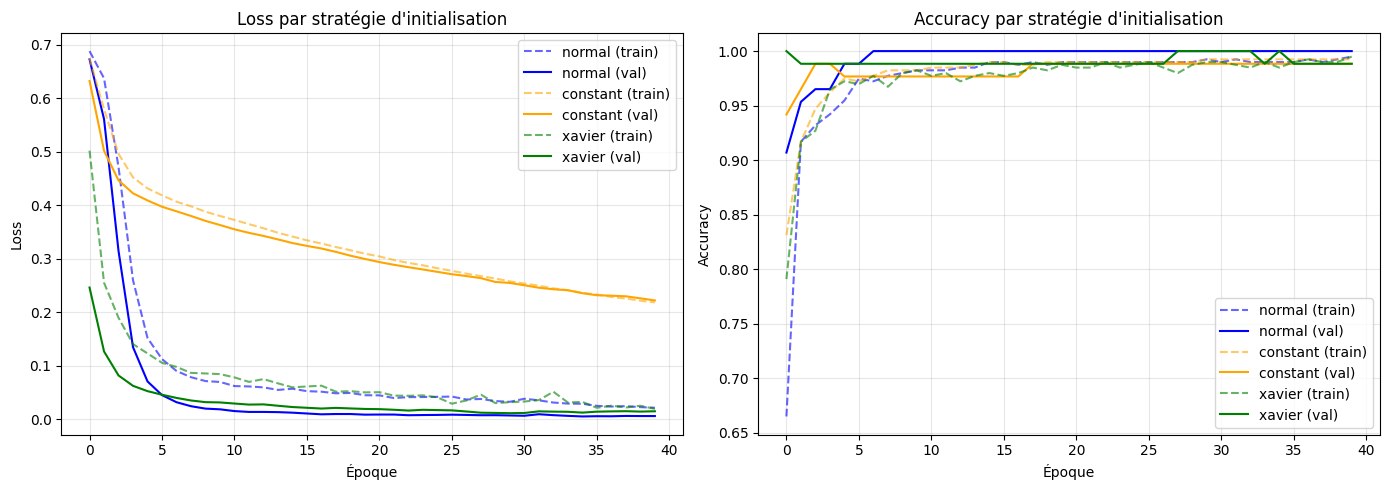

In [5]:
from deep_learning_project.training.train_mlp import train
from deep_learning_project.evaluation.classification import plot_training_history

optimizer_cls = torch.optim.Adam
criterion = nn.CrossEntropyLoss()
N_EPOCHS = 40

histories = {}
for strategy_name, init_fn in INIT_STRATEGIES.items():
    set_seed(42)
    model = MLP(input_dim=n_features, hidden_dims=[64, 32], output_dim=n_classes,
                activation="relu", dropout_p=0.2).to(device)
    model.apply(init_fn)
    optimizer = optimizer_cls(model.parameters(), lr=1e-3)

    history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=N_EPOCHS,
        checkpoint_filename=f"mlp_{strategy_name}_best.pt",
        verbose=False,
    )
    histories[strategy_name] = history
    print(f"[{strategy_name:8s}] Meilleure val_acc={max(history['val_acc']):.4f} "
          f"à l'époque {history['best_epoch']}")

# Visualiser les courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"normal": "blue", "constant": "orange", "xavier": "green"}
for strategy_name, history in histories.items():
    axes[0].plot(history["train_loss"], color=colors[strategy_name],
                 linestyle="--", alpha=0.6, label=f"{strategy_name} (train)")
    axes[0].plot(history["val_loss"], color=colors[strategy_name],
                 label=f"{strategy_name} (val)")
    axes[1].plot(history["train_acc"], color=colors[strategy_name],
                 linestyle="--", alpha=0.6, label=f"{strategy_name} (train)")
    axes[1].plot(history["val_acc"], color=colors[strategy_name],
                 label=f"{strategy_name} (val)")
axes[0].set_title("Loss par stratégie d'initialisation")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Accuracy par stratégie d'initialisation")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
from deep_learning_project.utils.io import save_figure
save_figure(fig, "mlp_init_strategies_comparison.png")
plt.show()

## 6. Entraînement Final (Xavier)

L'initialisation **Xavier (Glorot)** s'est révélée optimale dans notre expérience : convergence plus rapide et meilleure accuracy de validation. Nous l'utilisons pour entraîner le **modèle final** sur 60 époques, avec :

- **Weight decay** (`1e-4`) : régularisation L2 pour limiter le sur-apprentissage
- **Sauvegarde du meilleur checkpoint** : le modèle avec la meilleure `val_loss` est conservé automatiquement

Après l'entraînement, le meilleur checkpoint est rechargé pour l'évaluation finale.

Training:   0%|          | 0/60 [00:00<?, ?epoch/s]

Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_final_best.pt
Checkpoint saved to C:\_PROJECTS\deep-le

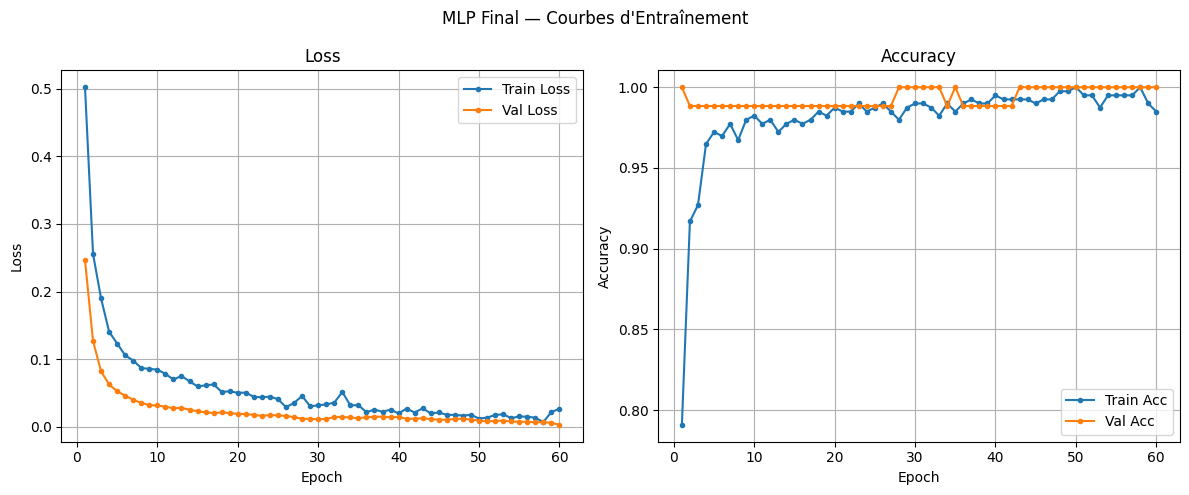

In [6]:
from deep_learning_project.utils.io import load_checkpoint

# Entraîner le modèle final avec Xavier (meilleure stratégie)
set_seed(42)
best_model = MLP(input_dim=n_features, hidden_dims=[64, 32], output_dim=n_classes,
                 activation="relu", dropout_p=0.2).to(device)
best_model.apply(INIT_STRATEGIES["xavier"])
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)

final_history = train(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=60,
    checkpoint_filename="mlp_final_best.pt",
    verbose=True,
)

# Recharger le meilleur checkpoint
ckpt = load_checkpoint(best_model, "mlp_final_best.pt", device)
print(f"\nMeilleur modèle chargé depuis l'époque {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

fig = plot_training_history(final_history, title="MLP Final \u2014 Courbes d'Entraînement",
                             save_filename="mlp_final_training_curves.png")
plt.show()

## 7. Évaluation

L'évaluation finale est réalisée sur le **jeu de test** (données jamais vues pendant l'entraînement ni la validation). Nous calculons l'ensemble des métriques de classification :

- **Accuracy** : proportion de prédictions correctes
- **Précision** : $\frac{\text{VP}}{\text{VP} + \text{FP}}$ — qualité des prédictions positives
- **Rappel** : $\frac{\text{VP}}{\text{VP} + \text{FN}}$ — capacité à détecter les vrais positifs
- **F1-Score** : $\frac{2 \times \text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}$

La **matrice de confusion** permet de visualiser les types d'erreurs commises par le modèle.

Metrics saved to C:\_PROJECTS\deep-learning\outputs\metrics\classification_report.json
=== Rapport de Classification (Jeu de Test) ===
  Accuracy  : 0.9419
  Précision : 0.9452
  Rappel    : 0.9419
  F1-Score  : 0.9423
Figure saved to C:\_PROJECTS\deep-learning\outputs\figures\mlp_confusion_matrix.png


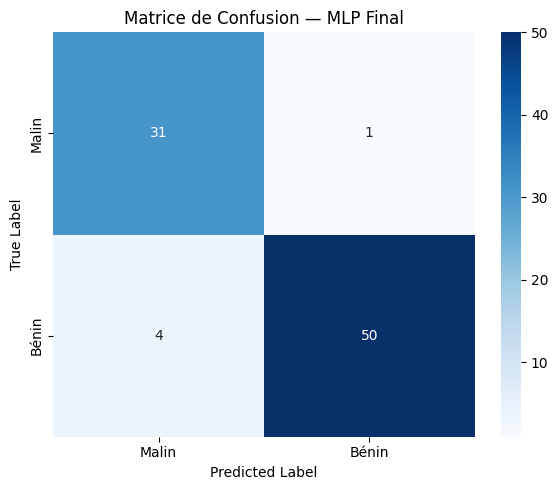


=== Comparaison : Sequential vs Custom ===
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to C:\_PROJECTS\deep-learning\outputs\models\mlp_seq_best.pt
Checkpoint saved to 

WindowsPath('C:/_PROJECTS/deep-learning/outputs/metrics/mlp_comparison.json')

In [7]:
from deep_learning_project.evaluation.classification import (
    classification_report, plot_confusion_matrix, get_predictions,
    compute_accuracy, compute_precision, compute_recall, compute_f1
)

# Rapport complet sur le jeu de test
report = classification_report(
    best_model, test_loader, device,
    class_names=["Malin", "Bénin"]
)

print("=== Rapport de Classification (Jeu de Test) ===")
print(f"  Accuracy  : {report['accuracy']:.4f}")
print(f"  Précision : {report['precision']:.4f}")
print(f"  Rappel    : {report['recall']:.4f}")
print(f"  F1-Score  : {report['f1']:.4f}")

fig = plot_confusion_matrix(
    report["confusion_matrix"],
    class_names=["Malin", "Bénin"],
    title="Matrice de Confusion \u2014 MLP Final",
    save_filename="mlp_confusion_matrix.png"
)
plt.show()

# Comparaison Sequential vs Custom
print("\n=== Comparaison : Sequential vs Custom ===")
set_seed(42)
model_seq_trained = build_sequential_mlp(n_features, [64, 32], n_classes, dropout_p=0.2).to(device)
# Apply xavier init manually to sequential model layers
for layer in model_seq_trained:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)
optimizer_seq = torch.optim.Adam(model_seq_trained.parameters(), lr=1e-3)
history_seq = train(model_seq_trained, train_loader, val_loader, optimizer_seq,
                     criterion, device, epochs=60, checkpoint_filename="mlp_seq_best.pt", verbose=False)
load_checkpoint(model_seq_trained, "mlp_seq_best.pt", device)

y_true_custom, y_pred_custom = get_predictions(best_model, test_loader, device)
y_true_seq, y_pred_seq = get_predictions(model_seq_trained, test_loader, device)

comparison_df = pd.DataFrame({
    "Modèle": ["Sequential", "Custom (MLP)"],
    "Accuracy": [compute_accuracy(y_true_seq, y_pred_seq), compute_accuracy(y_true_custom, y_pred_custom)],
    "Précision": [compute_precision(y_true_seq, y_pred_seq), compute_precision(y_true_custom, y_pred_custom)],
    "Rappel": [compute_recall(y_true_seq, y_pred_seq), compute_recall(y_true_custom, y_pred_custom)],
    "F1": [compute_f1(y_true_seq, y_pred_seq), compute_f1(y_true_custom, y_pred_custom)],
})
print(comparison_df.to_string(index=False))
from deep_learning_project.utils.io import save_metrics_json
save_metrics_json({"sequential": history_seq, "custom": final_history}, "mlp_comparison.json")

## 8. Résultats et Interprétation

### Stratégies d'initialisation

- **Xavier converge plus vite** que Normal ou Constant : l'initialisation de Glorot maintient les variances des activations et des gradients équilibrées à travers les couches, ce qui accélère la descente de gradient.
- **L'initialisation constante échoue** (problème de symétrie) : lorsque tous les neurones d'une couche ont exactement les mêmes poids, ils calculent la même chose et leurs gradients sont identiques. Ils restent donc indistinguables tout au long de l'entraînement — le réseau n'exploite pas sa capacité.
- **L'initialisation normale** fonctionne, mais converge plus lentement et peut être plus sensible au taux d'apprentissage.

### MLP vs Sequential

Sur cette tâche simple, les deux approches atteignent des performances similaires. Cependant, la **classe `MLP`** est nettement plus extensible : elle permet d'ajouter facilement des skip connections, des normalisations, des têtes multiples, ou des méthodes d'analyse (nombre de paramètres, formes des couches).

### Breast Cancer : métriques attendues

Une **accuracy > 95%** est attendue sur ce dataset, car les classes sont bien séparées dans l'espace des 30 caractéristiques. Cependant, dans un contexte clinique réel, le **compromis précision/rappel** est crucial :

- Un **rappel élevé** (sensibilité) est prioritaire : mieux vaut signaler un faux positif (bénin classifié malin) qu'un faux négatif (malin non détecté).
- Le **F1-score** offre un bon équilibre pour comparer les modèles en tenant compte des deux types d'erreurs.

## 9. Conclusion

Dans ce notebook, nous avons couvert les **fondamentaux de PyTorch** à travers un cas concret de classification binaire :

- **`nn.Module`** : la classe de base pour définir tout modèle PyTorch, avec la méthode `forward()` au cœur du calcul
- **`state_dict()`** et `named_parameters()` : outils essentiels pour inspecter, sauvegarder et charger un modèle
- **Stratégies d'initialisation** : Xavier surpasse les initialisations naïves (normale, constante) en assurant une bonne propagation des gradients
- **Pipeline d'entraînement complet** : chargement des données, boucle d'entraînement, sauvegarde des checkpoints, évaluation avec métriques multiples

---

**Prochain notebook** : `02_cnn_images.ipynb` — traitement d'images avec des **réseaux convolutifs (CNN)**, où l'inductive bias spatial de la convolution remplace les couches entièrement connectées pour exploiter la structure locale des images.